In [ ]:
import pandas as pd
data = pd.read_csv("student.csv")
print(data.head())
print(data.tail())
print(data.info())
print(data.describe())
X = data[['Math', 'Reading']].values
Y = data['Writing'].values


   Math  Reading  Writing
0    48       68       63
1    62       81       72
2    79       80       78
3    76       83       79
4    59       64       62
     Math  Reading  Writing
995    72       74       70
996    73       86       90
997    89       87       94
998    83       82       78
999    66       66       72
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Math     1000 non-null   int64
 1   Reading  1000 non-null   int64
 2   Writing  1000 non-null   int64
dtypes: int64(3)
memory usage: 23.6 KB
None
              Math      Reading      Writing
count  1000.000000  1000.000000  1000.000000
mean     67.290000    69.872000    68.616000
std      15.085008    14.657027    15.241287
min      13.000000    19.000000    14.000000
25%      58.000000    60.750000    58.000000
50%      68.000000    70.000000    69.500000
75%      78.000000    81.000000 

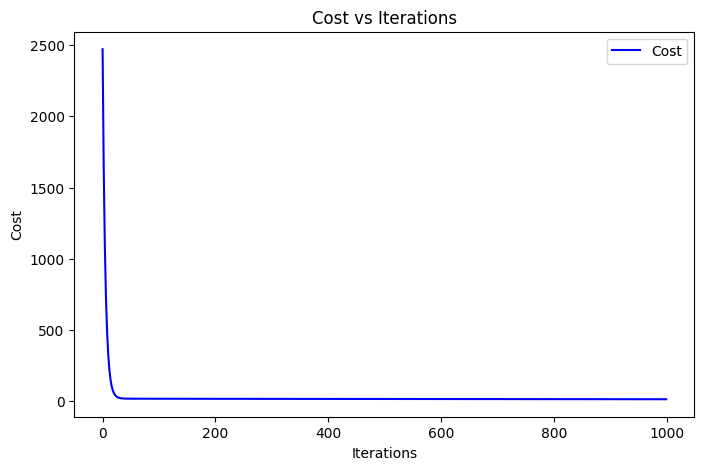

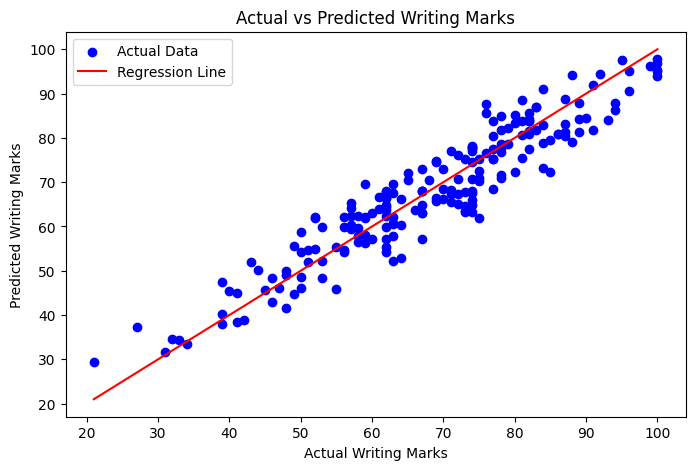

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
W = np.zeros((X_train.shape[1],1))
alpha = 0.00001
iterations = 1000

def gradient_descent(X, Y, W, alpha, iterations):
    m = len(Y)
    cost_history = []
    for _ in range(iterations):
        Y_pred = X @ W
        W -= alpha * (X.T @ (Y_pred - Y.reshape(-1,1)))/m
        cost_history.append(((Y_pred - Y.reshape(-1,1))**2).mean()/2)
    return W, cost_history

W_optimal, cost_history = gradient_descent(X_train, Y_train, W, alpha, iterations)
Y_pred = X_test @ W_optimal

plt.figure(figsize=(8,5))
plt.plot(cost_history, color='blue', label='Cost')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(Y_test, Y_pred, color='blue', label='Actual Data')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', label='Regression Line')
plt.xlabel("Actual Writing Marks")
plt.ylabel("Predicted Writing Marks")
plt.title("Actual vs Predicted Writing Marks")
plt.legend()
plt.show()


In [21]:
def cost_function(X, Y, W):
    m = len(Y)
    Y_pred = np.dot(X, W)
    cost = (1/(2*m)) * np.sum((Y_pred - Y.reshape(-1,1))**2)
    return cost

X_test_case = np.array([[1, 2], [3, 4], [5, 6]])
Y_test_case = np.array([3, 7, 11])
W_test_case = np.array([1, 1])
cost = cost_function(X_test_case, Y_test_case, W_test_case)
print("Cost function test output:", cost)  # Should print 0

Cost function test output: 32.0


In [22]:
def rmse(Y, Y_pred):
    return np.sqrt(np.mean((Y_pred - Y.reshape(-1,1))**2))

def r2(Y, Y_pred):
    mean_y = np.mean(Y)
    ss_tot = np.sum((Y - mean_y)**2)
    ss_res = np.sum((Y.reshape(-1,1) - Y_pred)**2)
    return 1 - (ss_res / ss_tot)

model_rmse = rmse(Y_test, Y_pred)
model_r2 = r2(Y_test, Y_pred)
print("RMSE on Test Set:", model_rmse)
print("R² on Test Set:", model_r2)


RMSE on Test Set: 5.2798239764188635
R² on Test Set: 0.8886354462786421
